# Notebook 3: Does a protein localize to a cellular compartment?

In [ ]:
%pip install git+https://github.com/bobiac/bobiac-tools.git
%pip install matplotlib
%pip install numpy
%pip install scikit-image
%pip install scipy
%pip install tifffile
%pip install imagecodecs
%pip install pandas
%pip install seaborn

## Overview

In this notebook, we will learn how to assess whether a protein localizes to a cellular compartment. In this example, the compartment is the cell membrane.

### Dataset
Our data consists of fluorescence images with five channels:
| Channel | Staining | Staining Description |
|---------|---------|----------------|
| 0 | Hoechst | Nuclear stain |
| 1 | Phalloidin | F-actin stain; whole cell marker |
| 2 | Protein A | Spot pattern |
| 3 | Protein B | Spot pattern |
| 4 | Protein C | Spot pattern |

***

## 0. Importing libraries

***

## 2. Load image, mask and spot table
First, we load all the data that we will need for this notebook.

### Visualy inspect the images, masks and spots
To be sure that the data we are workin with is corrects, we visualise it here.

Using the `focus` attribute in `overlay` we can zoom in to view single objects.

***

## 3. Make An Analysis Plan 

### Question
Does Protein C localize to the cell membrane?

### Approach 
Another common task is to ask whether a distribution of objects is close to a cellular compartment; in this case the cell membrane. At first glance, this question might seem different from what we have done so far, but it is just a variation of the co-localisation analysis we have already done. The key is to transform the cell membrane region into a set of points. This way we can do the exact same analysis as above.

### Workflow

#### 1. Generate a reference for comparison
Randomly distributed set of points inside each cell's cytoplasm. We will call this the **random dataset**, which we will compare to our **protein datasets**.

#### 2. Measure the nearest neighbor distance
For every spot in dataset C, identify the closest spot in the cell membrane dataset and measure the distance.

#### 3. Calculate the average nearest neighbour distance
Average the two distances across all spots in the cell.

#### 4. Calculate the Clark-Evans Index
Calculate the ratio of the average C-membrane distance compared to the C-random distance. 
    - **Ratio = 1:** Spots in membrane dataset and the spots in the random dataset are both distributed independently of spots in dataset C
    - **Ratio < 1:** Spots in dataset C co-localise with spots in the membrane dataset
    - **Ratio > 1:** Spots in dataset C and and membrane avoid each other  

#### 5. Calculate the p-value of the Clark-Evans Index
Calculate the p-value using a comparison of multiple random patterns.

#### 6. Calculate the reverse direction of comparison
Measure the distance of every spot in the membrane dataset to dataset C, then repeat the analysis.

***

## 4. Perform the Colocalization Analysis

### ✍️ Exercise: Perform the analysis

Use the cross nearest neighbour analysis we developed above to find out if protein C localises preferentially to the cell membrane.

Hints: 
* The code snippet below illustrates how a boolean mask of a whole single cell can be turned into its boundary and subsequently into a list of boundary coordinates (points).
* Think carefully about which populations to randomise and compare.

(<Figure size 674.314x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

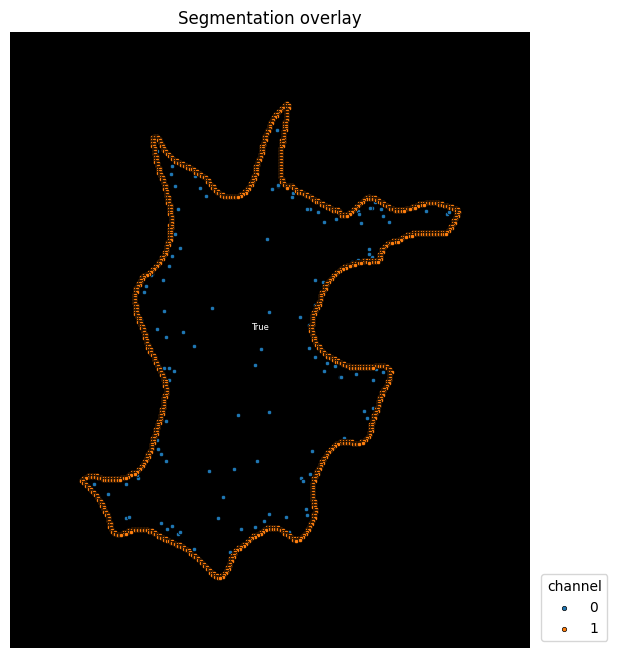

In [ ]:
from skimage.segmentation import find_boundaries

cell_id = 63

spots_C = df_spots.loc[(df_spots['channel']==2) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()

boundary = find_boundaries(mask == cell_id)
coords = np.argwhere(boundary)

overlay_labels(label_mask=boundary, coordinates=[spots_C,  coords],  focus_object=True)

In [ ]:
def NNdist_target(spots_from, spots_to, mask, cell_id, n_repeats):
    """
    Calculate the nearest neighbour distance from `spots_from` to `spots_to`.
    """

    n_from = spots_from.shape[0]

    # observed NN distances
    nn_obs = KDTree(spots_to).query(spots_from, k=1)[0].mean()

    # randomised NN distances
    sims = []
    for _ in range(n_repeats):
        rnd = random_points_in_mask(mask, cell_label=cell_id, n=n_from)

        sims.append(KDTree(rnd_B).query(rnd, k=1)[0].mean())

    sims = np.array(sims)

    return {
        'nn_observed':    nn_obs,
        'nn_random':      sims.mean(),
        'ce':             nn_obs / sims.mean(),
        'pval':           (sims <= nn_obs).mean(),
    }


In [ ]:
n_repeats = 10

results = []
for cell_id in df_cell['label'].unique():
    boundary = find_boundaries(mask == cell_id)
    coords = np.argwhere(boundary)
    spots_C = df_spots.loc[(df_spots['channel']==2) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()

    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNdist_target(spots_from=spots_C, spots_to=coords, mask=mask, cell_id=cell_id, n_repeats=n_repeats))

df_boundary = pd.DataFrame(results)
df_boundary

,nn_observed,nn_random,ce,pval
0,3.730943,412.027304,0.009055,0.0
1,4.867899,289.938812,0.016789,0.0
2,5.118525,986.041290,0.005191,0.0
3,4.387293,325.795797,0.013466,0.0
4,3.287399,1020.099624,0.003223,0.0
...,...,...,...,...
89,5.160171,222.376031,0.023205,0.0
90,4.033176,830.678799,0.004855,0.0
91,6.320505,653.078410,0.009678,0.0
92,5.492485,731.050070,0.007513,0.0


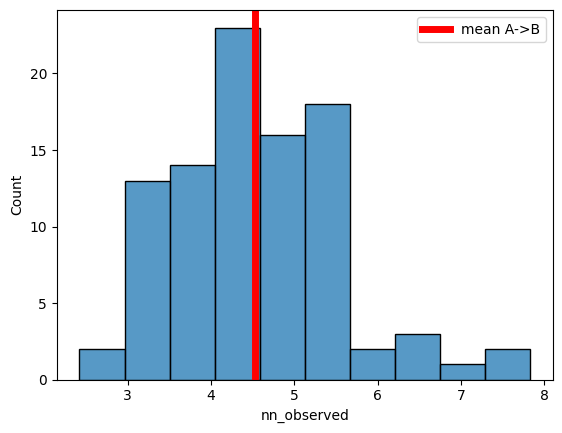

In [84]:
sns.histplot(
    df_boundary,
    x='nn_observed',

)
plt.axvline(df_boundary['nn_observed'].mean(), c='red', lw=5, label='mean A->B')
# plt.axvline(df_boundary['nn_random'].mean(), c='green', lw=5, label='mean A->random')
plt.legend()

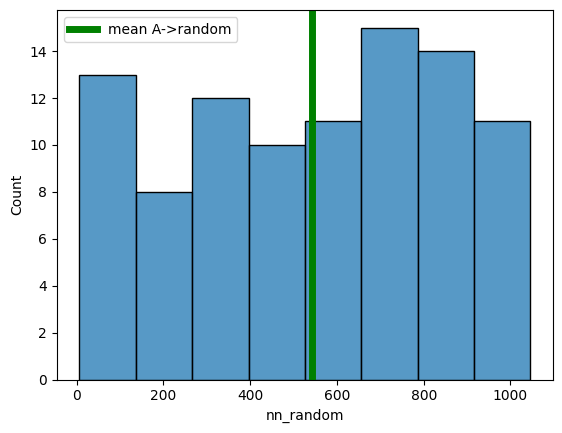

In [83]:
sns.histplot(
    df_boundary,
    x='nn_random',
)
# plt.axvline(df_boundary['nn_observed'].mean(), c='red', lw=5, label='mean A->B')
plt.axvline(df_boundary['nn_random'].mean(), c='green', lw=5, label='mean A->random')
plt.legend()

(0.0, 0.2)

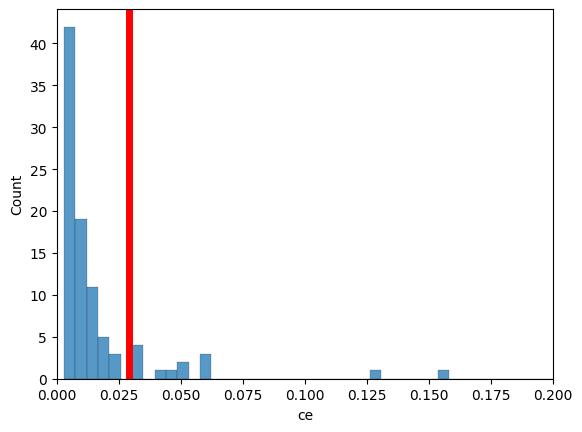

In [85]:
sns.histplot(
    df_boundary,
    x='ce',
)
plt.axvline(df_boundary['ce'].mean(), c='red', lw=5)
plt.xlim(0,0.2)

So, definitely, Protein C localises close to the cell membrane with an average distance of 4.5 pixels.